# Bankrupcy Prediction
## Import data

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [62]:
df1 = pd.read_csv('../data/1year.arff',skiprows=69,header=None,na_values='?')
df2 = pd.read_csv('../data/2year.arff',skiprows=69,header=None,na_values='?')
df3 = pd.read_csv('../data/3year.arff',skiprows=69,header=None,na_values='?')
df4 = pd.read_csv('../data/4year.arff',skiprows=69,header=None,na_values='?')
df5 = pd.read_csv('../data/5year.arff',skiprows=69,header=None,na_values='?')
df1["year"] = 1
df2["year"] = 2
df3["year"] = 3
df4["year"] = 4
df5["year"] = 5
df_final = pd.concat([df1, df2, df3, df4, df5], axis=0)
df_final.head()


,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


In [63]:
new_column_names = [f'X{i+1}' for i in range(64)]
new_column_names.append('Bankrupcy')
new_column_names.append('Year')
df_final.columns = new_column_names
df_final.head()



,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupcy,Year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


In [64]:
new_column_names = [f'X{i+1}' for i in range(64)]
new_column_names.append('Bankrupcy')
new_column_names.append('Year')

## EDA
### Missing values and Imputations

In [65]:
missing = pd.DataFrame(df_final.isnull().sum(), columns=['Missing'])
missing['Percentage'] = (missing['Missing'] / len(df_final)) * 100
missing = missing.sort_values(by='Percentage', ascending=True)
missing

,Missing,Percentage
Year,0,0.000000
Bankrupcy,0,0.000000
X55,1,0.002304
X59,7,0.016127
X57,7,0.016127
...,...,...
X45,2147,4.946435
X60,2152,4.957954
X27,2764,6.367930
X21,5854,13.486925


In [66]:
missing

,Missing,Percentage
Year,0,0.000000
Bankrupcy,0,0.000000
X55,1,0.002304
X59,7,0.016127
X57,7,0.016127
...,...,...
X45,2147,4.946435
X60,2152,4.957954
X27,2764,6.367930
X21,5854,13.486925


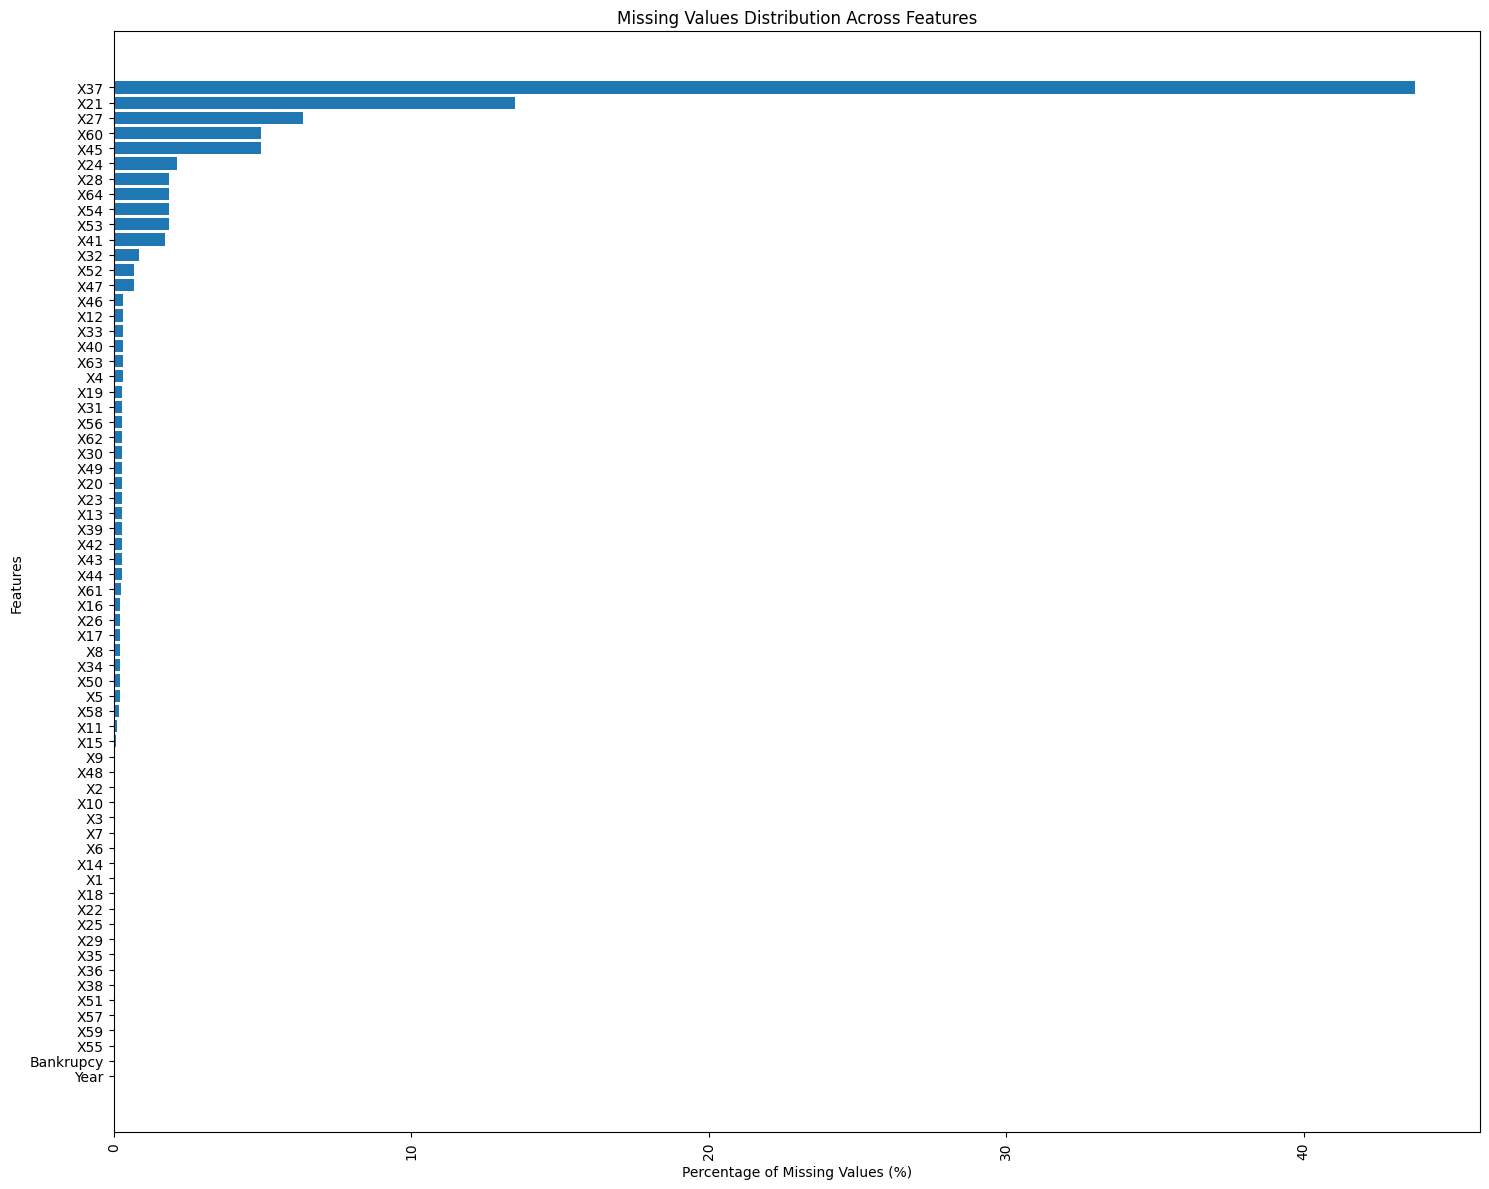

In [67]:
# Create the plot
plt.figure(figsize=(15, 12))
plt.barh(missing.index, missing.Percentage)
plt.xticks(rotation=90)
plt.title('Missing Values Distribution Across Features')
plt.xlabel('Percentage of Missing Values (%)')
plt.ylabel('Features')
plt.tight_layout()
# Save the plot
# plt.savefig('../plots/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

- X37 is (current assets - inventories) / long-term liabilities, there are many other related variables to replace X37
- We remove X37
- X21 and X27 are to be remained and imputed with KNNImputer

In [68]:
df_final = df_final.drop(columns=['X37'])

In [69]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='uniform')
df_imputed = pd.DataFrame(imputer.fit_transform(df_final), columns=df_final.columns)

df_imputed.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupcy,Year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0.0,1.0
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0.0,1.0
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0.0,1.0
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0.0,1.0
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0.0,1.0


### Distribution of Bankrupcy by Year

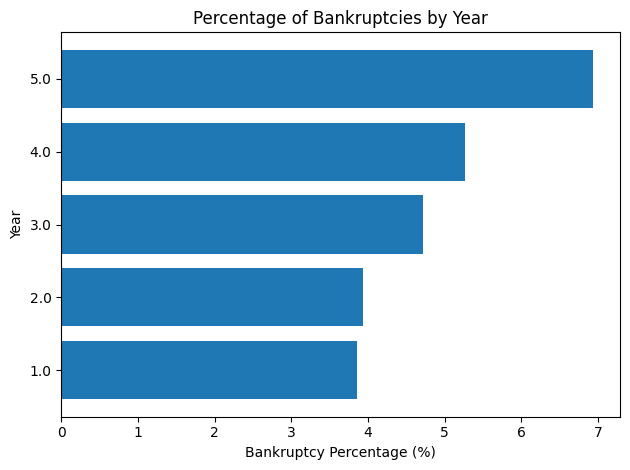

In [70]:
# Step 1: Group by Year and calculate counts
total_per_year = df_imputed.groupby('Year').size()
bankrupt_per_year = df_imputed[df_imputed['Bankrupcy'] == 1].groupby('Year').size()

# Step 2: Calculate percentage
percent_bankruptcy = (bankrupt_per_year / total_per_year * 100).fillna(0).sort_index()

# Step 3: Plot
plt.barh(percent_bankruptcy.index.astype(str), percent_bankruptcy.values)
plt.xlabel('Bankruptcy Percentage (%)')
plt.ylabel('Year')
plt.title('Percentage of Bankruptcies by Year')
plt.tight_layout()
plt.show()


### Cross Correlation Analysis

In [71]:
X = df_imputed.iloc[:, :-2]
y = df_imputed.iloc[:, -2]

- Calculate the cross correlation between 64 features
- Sort list the strong correlation pairs with R>0.95
- Print out the top 20 highest pairs

In [72]:
corr_matrix = X.corr().abs()

# Unstack to long format
corr_pairs = corr_matrix.unstack()

# Remove self-correlations and duplicate pairs
corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()

# Filter strong correlations
strong_corr = corr_pairs[corr_pairs > 0.95].sort_values(ascending=False)
print(strong_corr.head(20))

X7   X14    1.000000
X4   X46    0.999923
X20  X56    0.999878
X8   X17    0.999609
X19  X23    0.999291
     X31    0.999200
X43  X44    0.999021
X10  X38    0.998974
X53  X54    0.998750
X23  X31    0.998490
X56  X58    0.998202
X20  X58    0.998191
X3   X51    0.998160
X14  X18    0.995777
X7   X18    0.995759
X9   X36    0.995228
X43  X56    0.991564
X20  X43    0.991523
X16  X26    0.991151
X43  X58    0.989796
dtype: float64


In [73]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import fcluster    

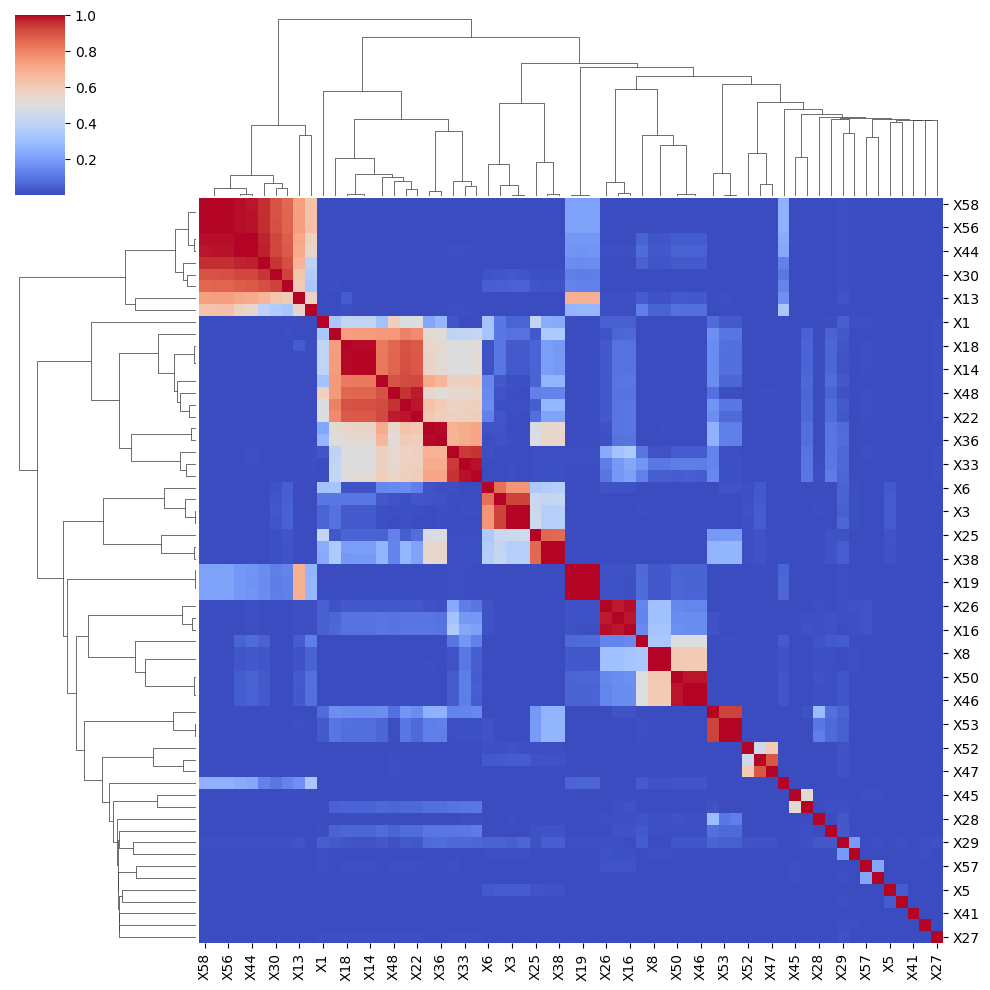

In [74]:
# Perform clustering manually and pass linkage to clustermap
linkage = sch.linkage(pdist(corr_matrix), method='average')
g = sns.clustermap(corr_matrix, row_linkage=linkage, col_linkage=linkage, cmap="coolwarm")

In [75]:
# Define number of clusters (e.g. 5)
cluster_labels = fcluster(linkage, t=8, criterion='maxclust')

# Map feature names to cluster labels
feature_names = corr_matrix.columns[g.dendrogram_col.reordered_ind]
cluster_map = pd.Series(cluster_labels, index=feature_names)

# Get top cluster (most frequent cluster ID)
top_cluster_id = cluster_map.value_counts().idxmax()
top_cluster_features = cluster_map[cluster_map == top_cluster_id].index.tolist()

print("Top cluster ID:", top_cluster_id)
print("Top cluster features:", top_cluster_features)


Top cluster ID: 8
Top cluster features: ['X44', 'X14', 'X36', 'X3', 'X51', 'X25', 'X31', 'X40', 'X17', 'X64', 'X54', 'X45', 'X61', 'X55', 'X59', 'X5', 'X15']


In [76]:
len(top_cluster_features)

17

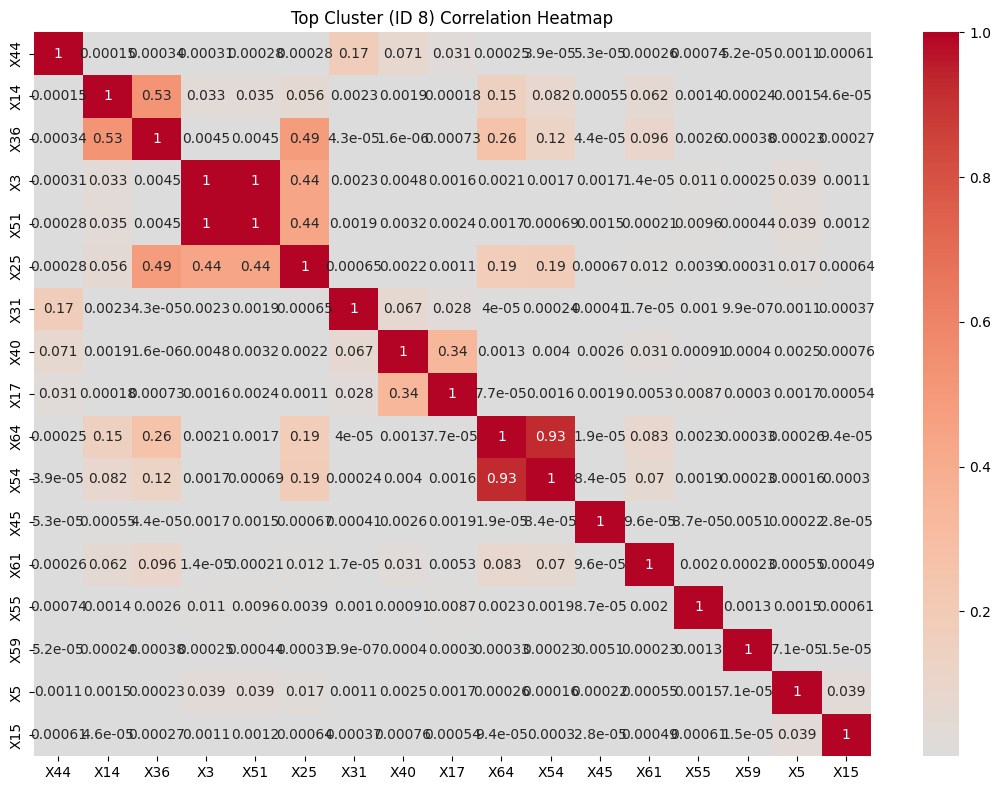

In [77]:
# Subset correlation matrix to only features in top cluster
corr_top = corr_matrix.loc[top_cluster_features, top_cluster_features]

# Plot heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(corr_top, annot=True, cmap='coolwarm', center=0)
plt.title(f"Top Cluster (ID {top_cluster_id}) Correlation Heatmap")
plt.tight_layout()
plt.show()

In [78]:
X_selected = X[corr_top.index]
X_selected = X_selected.drop(columns=['X51','X54'])
X_selected.head()

,X44,X14,X36,X3,X25,X31,X40,X17,X64,X45,X61,X55,X59,X5,X15
0,71.050,0.249760,1.7410,0.39641,0.50494,0.149420,0.662950,2.6349,7.4277,1.00970,5.1372,348690.0,0.001924,32.3510,497.42
1,111.510,0.258340,1.6996,0.47225,0.39542,0.152000,0.086422,2.0005,60.9870,0.51045,3.2732,2304.6,0.000000,14.7860,677.96
2,92.381,0.309060,1.3090,0.26713,0.28932,0.238150,0.322020,1.4369,5.2078,0.94807,3.9510,6332.7,0.694840,-1.1523,794.16
3,100.980,0.092704,1.3562,0.45879,0.57353,0.071428,0.401390,3.2537,5.5497,0.28720,3.6147,20545.0,0.000000,51.9520,917.01
4,84.574,0.187320,1.6278,0.22960,0.38677,0.115530,0.293040,1.6307,7.8980,0.73919,4.3158,3186.6,0.124440,-7.3128,1133.20


### VIF


In [79]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept) for VIF calculation
X1 = add_constant(X_selected)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X1.columns
vif_data['VIF'] = [variance_inflation_factor(X1.values, i)
                   for i in range(X1.shape[1])]

# Drop constant row if desired
vif_data = vif_data[vif_data['Feature'] != 'const']

print(vif_data)

   Feature       VIF
1      X44  1.038263
2      X14  1.893745
3      X36  2.694093
4       X3  1.515944
5      X25  2.432818
6      X31  1.037678
7      X40  1.141406
8      X17  1.129651
9      X64  1.089993
10     X45  1.000038
11     X61  1.016953
12     X55  1.000234
13     X59  1.000028
14      X5  1.003041
15     X15  1.001528


## Modeling with RF
RF and XGBoost are tree-based model hence does not really require feature selection
### Modeling RF1: Using entire data

In [80]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=123)

model_rf_all = RandomForestClassifier(n_estimators=100,random_state=123)
model_rf_all.fit(X_train,y_train)

y_pred = model_rf_all.predict(X_test)

print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      8285
         1.0       0.52      0.06      0.11       396

    accuracy                           0.95      8681
   macro avg       0.74      0.53      0.54      8681
weighted avg       0.94      0.95      0.94      8681

[[8263   22]
 [ 372   24]]
0.9546135237875821


In [81]:
%%time
from sklearn.model_selection import GridSearchCV
# Define parameter grid
rf = RandomForestClassifier(n_estimators=25,random_state=123)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_features': [5,10,15,20],
    'max_depth': [None, 1,3,5,7,9],
    'min_samples_split': [8,6,4],
    'min_samples_leaf': [4,2,1],
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit to your data
grid_search.fit(X_train, y_train)

# Best model and parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

### Modeling RF2: Using selected data

In [44]:
X_selected_train,X_selected_test,y_selected_train,y_selected_test = train_test_split(X_selected,y,train_size=0.8,random_state=123)


In [45]:

model_rf_selected = RandomForestClassifier(n_estimators=100,random_state=123)
model_rf_selected.fit(X_selected_train,y_selected_train)

y_pred2 = model_rf_selected.predict(X_selected_test)

print(classification_report(y_selected_test,y_pred2))
print(confusion_matrix(y_selected_test,y_pred2))
print(accuracy_score(y_selected_test,y_pred2))

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      8285
         1.0       0.07      0.01      0.02       396

    accuracy                           0.95      8681
   macro avg       0.51      0.50      0.50      8681
weighted avg       0.91      0.95      0.93      8681

[[8231   54]
 [ 392    4]]
0.9486234304803594


### Find the optimal hyperparameters

In [ ]:
%%time
# Grid search with 5-fold cross-validation
grid_search_selected = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
# Fit to your data
grid_search_selected.fit(X_selected_train, y_selected_train)

# Best model and parameters
print("Best Parameters:", grid_search_selected.best_params_)
print("Best Score:", grid_search_selected.best_score_)

### Important variables
- Plot 2 figures for feature importances for full and selected data

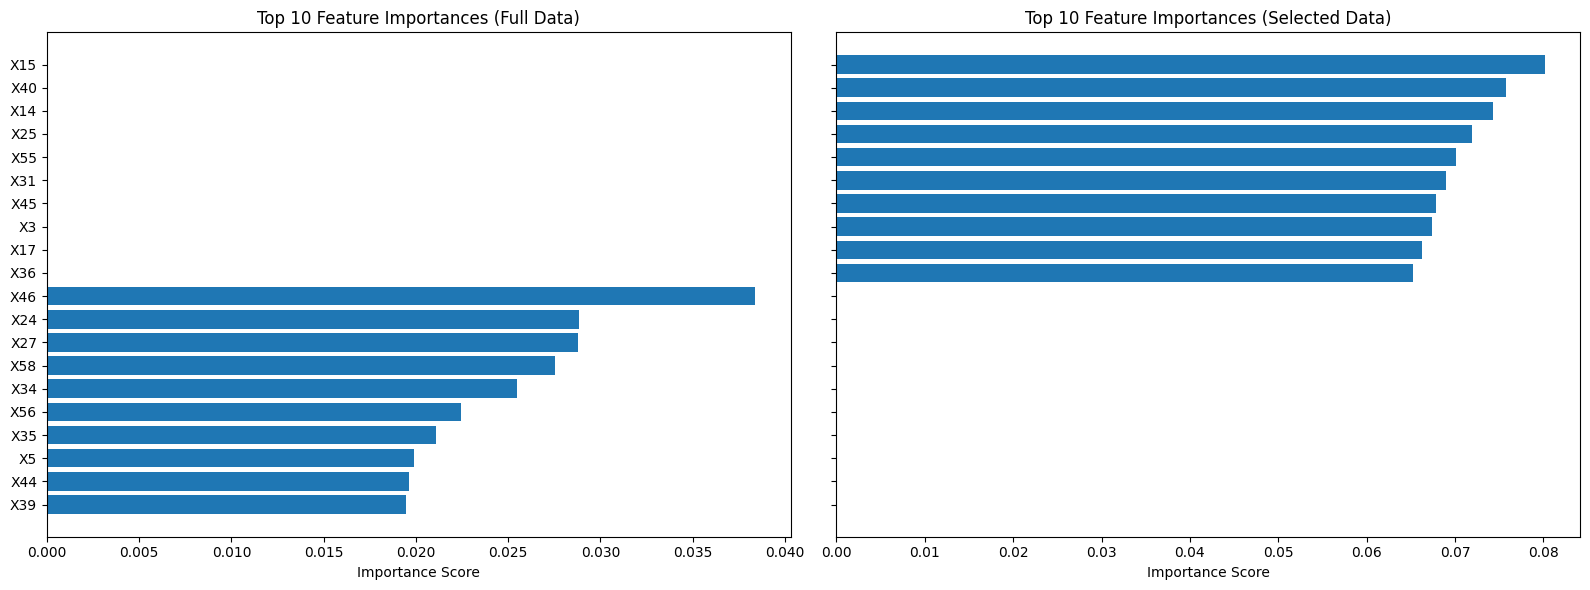

In [52]:
# Get feature importances
importances_selected  = model_rf_selected.feature_importances_
features = X_selected_train.columns
importances_full = model_rf_all.feature_importances_
features_full = X_train.columns 

# Display top features
importance_df_selected = pd.DataFrame({'Feature': features, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()


## XGBoost
### Selected data

In [83]:
%%time

# Train XGBoost classifier
model_xgb_selected = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='logloss',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=3,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=42           # for reproducibility
)

model_xgb_selected.fit(X_selected_train, y_selected_train)

# Make predictions
y_pred = model_xgb_selected.predict(X_selected_test)

print(classification_report(y_selected_test,y_pred))
print(confusion_matrix(y_selected_test,y_pred))
print(accuracy_score(y_selected_test,y_pred))


              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98      8285
         1.0       0.00      0.00      0.00       396

    accuracy                           0.95      8681
   macro avg       0.48      0.50      0.49      8681
weighted avg       0.91      0.95      0.93      8681

[[8285    0]
 [ 396    0]]
0.9543831355834581
CPU times: user 254 ms, sys: 179 ms, total: 432 ms
Wall time: 153 ms


/Users/a46791130/anaconda3/envs/myenv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:33:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/a46791130/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a46791130/anaconda3/envs/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a46791130/anaconda3/envs/myen

In [85]:
model_xgb_selected.feature_importances_

array([0.03408776, 0.05411122, 0.04018868, 0.07045433, 0.12395615,
       0.04585433, 0.07585569, 0.04984892, 0.03996444, 0.08284147,
       0.04380298, 0.04945151, 0.02866649, 0.04493229, 0.21598378],
      dtype=float32)

In [28]:
params = {
    'subsample': 0.75,
    'max_depth': 4,
    'eval_metric': 'auc',
    'objective': 'binary:logistic'
}

def XGBRandomSearch(params, data, n_iter=30):
    best_score = 0
    best_params = 'error'

    max_d = np.random.choice([2, 4, 6, 8, 10, 12, 15, 20], n_iter)
    subs = 0.5 + np.random.random(n_iter) / 2
    colsample_bytree = 0.5 + np.random.random(n_iter) / 2
    colsample_bylevel = 0.5 + np.random.random(n_iter) / 2
    colsample_bynode = 0.5 + np.random.random(n_iter) / 2

    for i in range(n_iter):
        params['subsample'] = subs[i]
        params['max_depth'] = max_d[i]
        params['colsample_bytree'] = colsample_bytree[i]
        params['colsample_bylevel'] = colsample_bylevel[i]
        params['colsample_bynode'] = colsample_bynode[i]

        f = xgb.cv(
            params, 
            dtrain=data, 
            nfold=5,
            stratified=True, 
            metrics='auc',
            num_boost_round=1000, 
            early_stopping_rounds=10
        )

        if f.shape[0] == 1000:
            print("Warning hit limit")
        print(params, f['test-auc-mean'].max())

        if f['test-auc-mean'].max() > best_score:
            best_score = f['test-auc-mean'].max()
            best_params = copy.deepcopy(params)

    return f, best_score, best_params


In [29]:
traindata = xgb.DMatrix(X_selected_train, label=y_selected_train)
testdata = xgb.DMatrix(X_selected_test, label=y_selected_test)


In [36]:
%%time
b = xgb.train(params,evals=[(traindata,'train'),(testdata,'test')],num_boost_round=1000,dtrain=traindata,early_stopping_rounds=10)

[0]	train-auc:0.70000	test-auc:0.69911
[1]	train-auc:0.72412	test-auc:0.71167
[2]	train-auc:0.73167	test-auc:0.71752
[3]	train-auc:0.73522	test-auc:0.72261
[4]	train-auc:0.74154	test-auc:0.72887
[5]	train-auc:0.74704	test-auc:0.73575
[6]	train-auc:0.75396	test-auc:0.73601
[7]	train-auc:0.75548	test-auc:0.73678
[8]	train-auc:0.75754	test-auc:0.73874
[9]	train-auc:0.75876	test-auc:0.73814
[10]	train-auc:0.75962	test-auc:0.73847
[11]	train-auc:0.76174	test-auc:0.74004
[12]	train-auc:0.76298	test-auc:0.74321
[13]	train-auc:0.76449	test-auc:0.74368
[14]	train-auc:0.76686	test-auc:0.74655
[15]	train-auc:0.76913	test-auc:0.74663
[16]	train-auc:0.77095	test-auc:0.74776
[17]	train-auc:0.77214	test-auc:0.74635
[18]	train-auc:0.77354	test-auc:0.74639
[19]	train-auc:0.77439	test-auc:0.74730
[20]	train-auc:0.77531	test-auc:0.74849
[21]	train-auc:0.77692	test-auc:0.75032
[22]	train-auc:0.77693	test-auc:0.75044
[23]	train-auc:0.77834	test-auc:0.75137
[24]	train-auc:0.77992	test-auc:0.75282
[25]	train

In [ ]:
result = XGBRandomSearch(params,traindata,n_iter=30)

{'subsample': np.float64(0.5435646498507704), 'max_depth': np.int64(10), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.8353189348090797), 'colsample_bylevel': np.float64(0.5195938961271603), 'colsample_bynode': np.float64(0.7880786672089184)} 0.7528041259481837
{'subsample': np.float64(0.5101091987201629), 'max_depth': np.int64(20), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.6051912805369204), 'colsample_bylevel': np.float64(0.6414034812882048), 'colsample_bynode': np.float64(0.7960209656359195)} 0.7429967556478599
{'subsample': np.float64(0.916309922773969), 'max_depth': np.int64(12), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.5644631488274267), 'colsample_bylevel': np.float64(0.5600982806065844), 'colsample_bynode': np.float64(0.7861259528954367)} 0.7694068864690292
{'subsample': np.float64(0.8890783754749252), 'max_depth': np.int64(2), 'eval_metric': 'auc'

### Using All data


In [90]:
# Train XGBoost classifier
model_xgb_all = xgb.XGBClassifier(
    use_label_encoder=False,  # suppress label encoder warning
    eval_metric='logloss',    # standard metric for classification
    n_estimators=100,         # number of trees
    max_depth=3,              # tree depth
    learning_rate=0.1,        # step size shrinkage
    random_state=42           # for reproducibility
)

model_xgb_all.fit(X_train, y_train)

# Make predictions
y_pred = model_xgb_all.predict(X_test)

print(classification_report(y_selected_test,y_pred))
print(confusion_matrix(y_selected_test,y_pred))
print(accuracy_score(y_selected_test,y_pred))

/Users/a46791130/anaconda3/envs/myenv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:40:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98      8285
         1.0       0.93      0.11      0.19       396

    accuracy                           0.96      8681
   macro avg       0.95      0.55      0.59      8681
weighted avg       0.96      0.96      0.94      8681

[[8282    3]
 [ 353   43]]
0.9589908996659371


In [ ]:
b_all = xgb.train(params,evals=[(traindata,'train'),(testdata,'test')],num_boost_round=1000,dtrain=traindata,early_stopping_rounds=10)

In [38]:
result_all = XGBRandomSearch(params,traindata,n_iter=30)

{'subsample': np.float64(0.5435646498507704), 'max_depth': np.int64(10), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.8353189348090797), 'colsample_bylevel': np.float64(0.5195938961271603), 'colsample_bynode': np.float64(0.7880786672089184)} 0.9290773403131656
{'subsample': np.float64(0.5101091987201629), 'max_depth': np.int64(20), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.6051912805369204), 'colsample_bylevel': np.float64(0.6414034812882048), 'colsample_bynode': np.float64(0.7960209656359195)} 0.9178742905526137
{'subsample': np.float64(0.916309922773969), 'max_depth': np.int64(12), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.5644631488274267), 'colsample_bylevel': np.float64(0.5600982806065844), 'colsample_bynode': np.float64(0.7861259528954367)} 0.9433093653300146
{'subsample': np.float64(0.8890783754749252), 'max_depth': np.int64(2), 'eval_metric': 'auc'

In [40]:
all_dm = xgb.DMatrix(X,y)

In [41]:
result_allD = XGBRandomSearch(params,all_dm,n_iter=30)

{'subsample': np.float64(0.5435646498507704), 'max_depth': np.int64(10), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.8353189348090797), 'colsample_bylevel': np.float64(0.5195938961271603), 'colsample_bynode': np.float64(0.7880786672089184)} 0.9333721404926598
{'subsample': np.float64(0.5101091987201629), 'max_depth': np.int64(20), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.6051912805369204), 'colsample_bylevel': np.float64(0.6414034812882048), 'colsample_bynode': np.float64(0.7960209656359195)} 0.9267304729859417
{'subsample': np.float64(0.916309922773969), 'max_depth': np.int64(12), 'eval_metric': 'auc', 'objective': 'binary:logistic', 'colsample_bytree': np.float64(0.5644631488274267), 'colsample_bylevel': np.float64(0.5600982806065844), 'colsample_bynode': np.float64(0.7861259528954367)} 0.9471476964207713
{'subsample': np.float64(0.8890783754749252), 'max_depth': np.int64(2), 'eval_metric': 'auc'

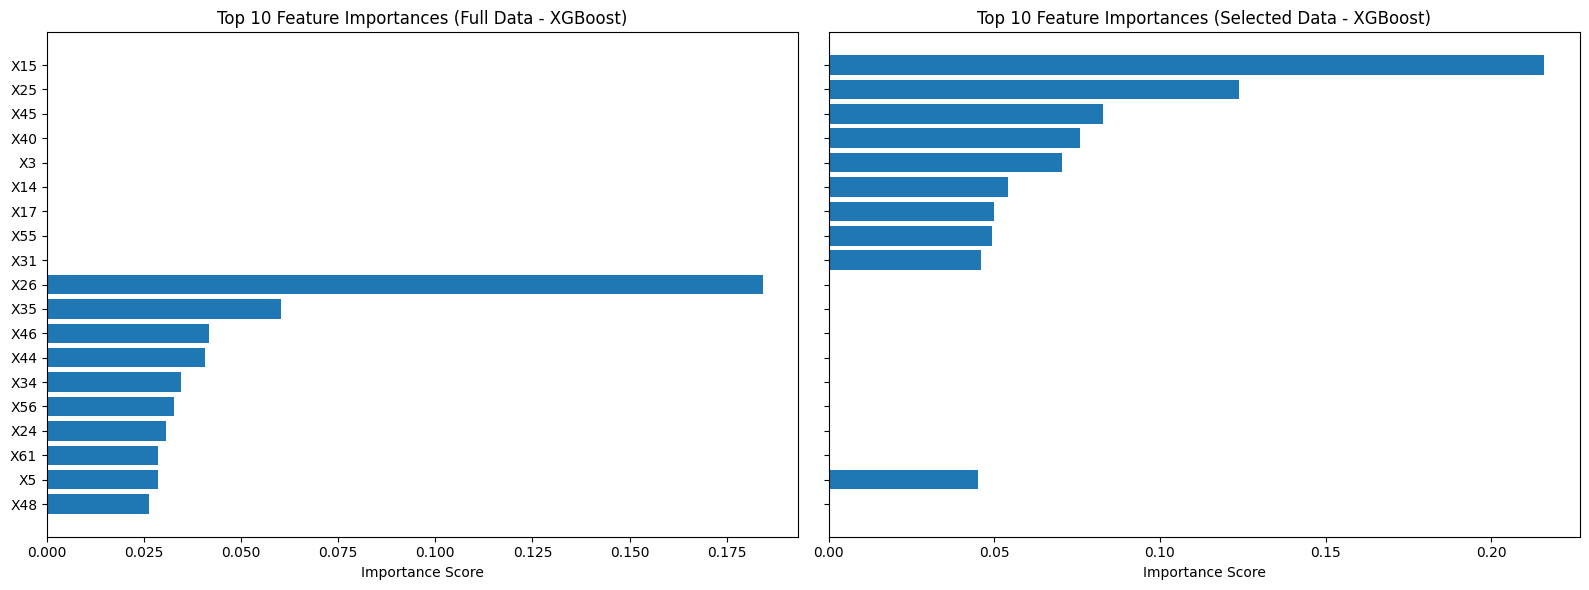

In [92]:
# Get feature importances
importances_full = model_xgb_all.feature_importances_
features_full = X_train.columns

importances_selected = model_xgb_selected.feature_importances_
features_selected = X_selected_train.columns

# Create DataFrames
importance_df_full = pd.DataFrame({'Feature': features_full, 'Importance': importances_full})
importance_df_full.sort_values(by='Importance', ascending=False, inplace=True)

importance_df_selected = pd.DataFrame({'Feature': features_selected, 'Importance': importances_selected})
importance_df_selected.sort_values(by='Importance', ascending=False, inplace=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Full feature importance
axes[0].barh(
    importance_df_full['Feature'].iloc[:10][::-1],
    importance_df_full['Importance'].iloc[:10][::-1]
)
axes[0].set_title("Top 10 Feature Importances (Full Data - XGBoost)")
axes[0].set_xlabel("Importance Score")

# Selected feature importance
axes[1].barh(
    importance_df_selected['Feature'].iloc[:10][::-1],
    importance_df_selected['Importance'].iloc[:10][::-1]
)
axes[1].set_title("Top 10 Feature Importances (Selected Data - XGBoost)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

### Comparative between RF and XGBoost